# MidTerm - DeepLearning - IUH - Giảng Viên: Đặng Thị Phúc
## 49 - Phan Tấn Tài - 22684181
### Câu 1

In [ ]:
import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Cài đặt sẵn các hàm thống kê

In [5]:
def dem_anh_theo_lop(thu_muc: Path) -> Dict[str, int]:
# đếm số lượng ảnh trong 3 thư mục train test val
    thong_ke = {}
    
    for thu_muc_lop in sorted(thu_muc.iterdir()):
        if thu_muc_lop.is_dir():
            ten_lop = thu_muc_lop.name
            so_luong = len(list(thu_muc_lop.glob("*.jpg"))) + len(list(thu_muc_lop.glob("*.png")))
            thong_ke[ten_lop] = so_luong
    
    return thong_ke


def phan_tich_kich_thuoc_anh(thu_muc: Path, so_luong_mau: int = 500) -> Tuple[List[int], List[int], List[float]]:
    """
    Phân tích kích thước và tỷ lệ khung hình của ảnh.
    """
    chieu_rong_list = []
    chieu_cao_list = []
    ty_le_list = []
    
    danh_sach_anh = []
    for thu_muc_lop in thu_muc.iterdir():
        if thu_muc_lop.is_dir():
            danh_sach_anh.extend(list(thu_muc_lop.glob("*.jpg")))
            danh_sach_anh.extend(list(thu_muc_lop.glob("*.png")))
    
    # Lấy mẫu ngẫu nhiên
    if len(danh_sach_anh) > so_luong_mau:
        danh_sach_anh = np.random.choice(danh_sach_anh, so_luong_mau, replace=False)
    
    for duong_dan_anh in danh_sach_anh:
        try:
            anh = Image.open(duong_dan_anh)
            w, h = anh.size
            chieu_rong_list.append(w)
            chieu_cao_list.append(h)
            ty_le_list.append(w / h)
        except Exception as e:
            print(f"Lỗi khi đọc ảnh {duong_dan_anh}: {e}")
    
    return chieu_rong_list, chieu_cao_list, ty_le_list


def hien_thi_anh_mau(thu_muc: Path, so_anh_moi_lop: int = 5) -> None:
    """
    Hiển thị ảnh mẫu từ mỗi lớp.
    """
    danh_sach_lop = sorted([d for d in thu_muc.iterdir() if d.is_dir()])
    so_lop = len(danh_sach_lop)
    
    fig, axes = plt.subplots(so_lop, so_anh_moi_lop, figsize=(so_anh_moi_lop * 3, so_lop * 3))
    
    for i, thu_muc_lop in enumerate(danh_sach_lop):
        ten_lop = thu_muc_lop.name
        danh_sach_anh = list(thu_muc_lop.glob("*.jpg")) + list(thu_muc_lop.glob("*.png"))
        
        # Lấy ngẫu nhiên ảnh mẫu
        anh_mau = np.random.choice(
            danh_sach_anh, 
            min(so_anh_moi_lop, len(danh_sach_anh)), 
            replace=False
        )
        
        for j, duong_dan_anh in enumerate(anh_mau):
            anh = Image.open(duong_dan_anh)
            
            if so_lop == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            
            ax.imshow(anh)
            ax.axis('off')
            
            if j == 0:
                ax.set_title(f'{ten_lop}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.suptitle(f'Mẫu ảnh từ tập {thu_muc.name}', fontsize=16, fontweight='bold', y=1.01)
    plt.show()

### check datasrouce

In [6]:
DATASET_DIR = Path("dataset_0806")

TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "valid"
TEST_DIR = DATASET_DIR / "test"

print(f"Train: {TRAIN_DIR.exists()}")
print(f"Valid: {VALID_DIR.exists()}")
print(f"Test: {TEST_DIR.exists()}")

Train: True
Valid: True
Test: True


### đếm số lượng ảnh

In [7]:
# Đếm số lượng ảnh theo lớp
train_counts = dem_anh_theo_lop(TRAIN_DIR)
valid_counts = dem_anh_theo_lop(VALID_DIR)
test_counts = dem_anh_theo_lop(TEST_DIR)

print("\nSố lượng ảnh trong tập Train:")
for ten_lop, so_luong in train_counts.items():
    print(f"  {ten_lop}: {so_luong}")

print("\nSố lượng ảnh trong tập Valid:")
for ten_lop, so_luong in valid_counts.items():
    print(f"  {ten_lop}: {so_luong}")

print("\nSố lượng ảnh trong tập Test:")
for ten_lop, so_luong in test_counts.items():
    print(f"  {ten_lop}: {so_luong}")


Số lượng ảnh trong tập Train:
  bacterial_leaf_blight: 781
  brown_spot: 795
  healthy: 794
  leaf_blast: 774

Số lượng ảnh trong tập Valid:
  bacterial_leaf_blight: 196
  brown_spot: 199
  healthy: 191
  leaf_blast: 194

Số lượng ảnh trong tập Test:
  bacterial_leaf_blight: 245
  brown_spot: 249
  healthy: 248
  leaf_blast: 242


In [9]:
df_thong_ke = pd.DataFrame({
    "Train": train_counts,
    "Valid": valid_counts,
    "Test": test_counts
})

df_thong_ke["Tổng"] = df_thong_ke.sum(axis=1)
df_thong_ke.loc["Tổng"] = df_thong_ke.sum()

print("\nBảng tổng hợp phân bố dữ liệu:")
print(df_thong_ke)


Bảng tổng hợp phân bố dữ liệu:
                       Train  Valid  Test  Tổng
bacterial_leaf_blight    781    196   245  1222
brown_spot               795    199   249  1243
healthy                  794    191   248  1233
leaf_blast               774    194   242  1210
Tổng                    3144    780   984  4908


In [10]:
# Tính tỷ lệ phần trăm
df_ty_le = df_thong_ke.div(df_thong_ke.loc["Tổng"]) * 100
df_ty_le = df_ty_le.drop("Tổng")

print("\nTỷ lệ phần trăm từng lớp:")
print(df_ty_le.round(2))


Tỷ lệ phần trăm từng lớp:
                       Train  Valid   Test   Tổng
bacterial_leaf_blight  24.84  25.13  24.90  24.90
brown_spot             25.29  25.51  25.30  25.33
healthy                25.25  24.49  25.20  25.12
leaf_blast             24.62  24.87  24.59  24.65


### Trực quan hoá

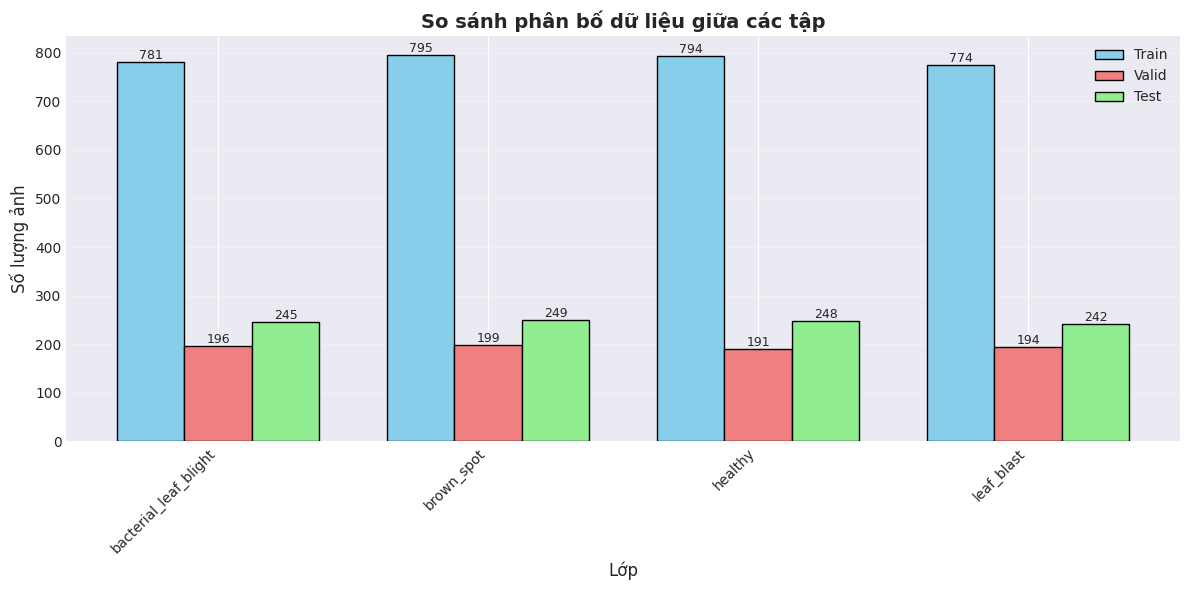

In [11]:
# Vẽ biểu đồ cột so sánh giữa các tập
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(train_counts))
width = 0.25

bars1 = ax.bar(x - width, list(train_counts.values()), width, label='Train', color='skyblue', edgecolor='black')
bars2 = ax.bar(x, list(valid_counts.values()), width, label='Valid', color='lightcoral', edgecolor='black')
bars3 = ax.bar(x + width, list(test_counts.values()), width, label='Test', color='lightgreen', edgecolor='black')

ax.set_xlabel('Lớp', fontsize=12)
ax.set_ylabel('Số lượng ảnh', fontsize=12)
ax.set_title('So sánh phân bố dữ liệu giữa các tập', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.keys(), rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Thêm giá trị trên cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Hiển thị 1 vài mẫu ảnh

Hiển thị ảnh mẫu từ tập Train:


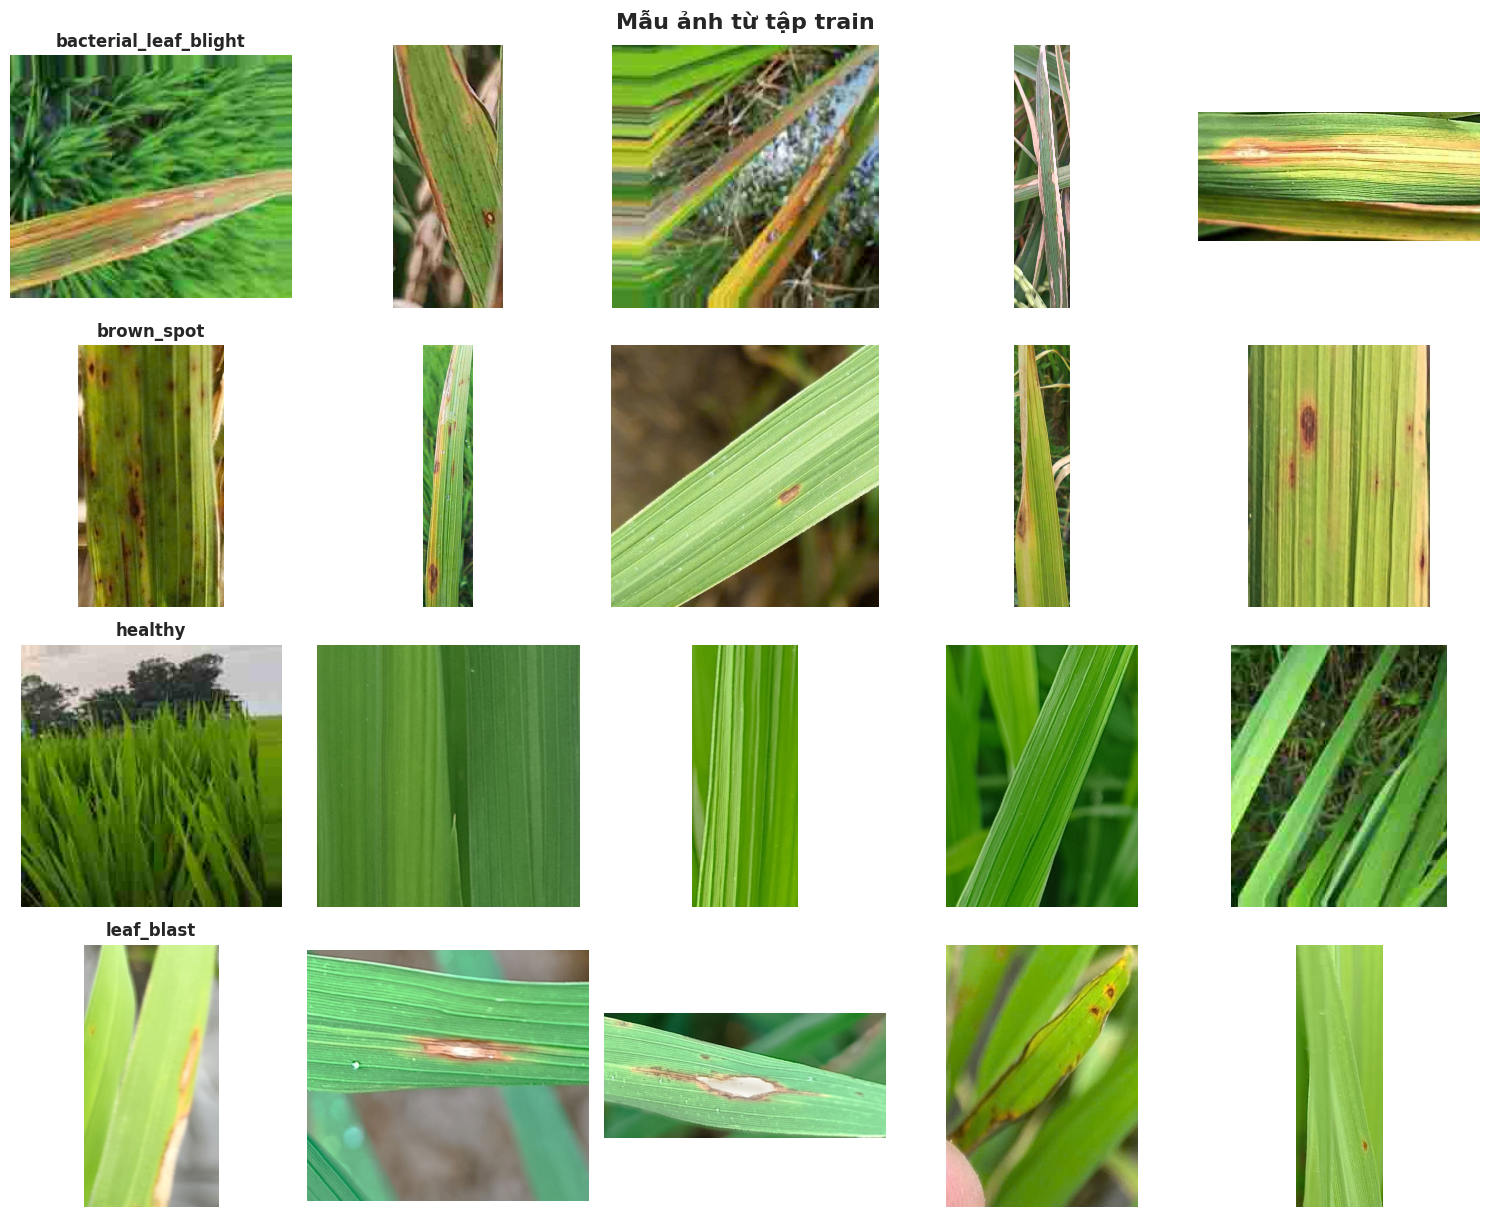

In [12]:
# Hiển thị ảnh mẫu từ tập Train
print("Hiển thị ảnh mẫu từ tập Train:")
hien_thi_anh_mau(TRAIN_DIR, so_anh_moi_lop=5)

### phân tích kích thước ảnh

In [13]:
# Phân tích kích thước ảnh
print("Phân tích kích thước ảnh từ tập Train:")
chieu_rong, chieu_cao, ty_le = phan_tich_kich_thuoc_anh(TRAIN_DIR, so_luong_mau=500)

print(f"Số lượng ảnh phân tích: {len(chieu_rong)}")
print(f"Chiều rộng - Trung bình: {np.mean(chieu_rong):.2f} px, Min: {np.min(chieu_rong)} px, Max: {np.max(chieu_rong)} px")
print(f"Chiều cao - Trung bình: {np.mean(chieu_cao):.2f} px, Min: {np.min(chieu_cao)} px, Max: {np.max(chieu_cao)} px")
print(f"Tỷ lệ khung hình - Trung bình: {np.mean(ty_le):.2f}, Min: {np.min(ty_le):.2f}, Max: {np.max(ty_le):.2f}")

Phân tích kích thước ảnh từ tập Train:
Số lượng ảnh phân tích: 500
Chiều rộng - Trung bình: 828.82 px, Min: 19 px, Max: 10774 px
Chiều cao - Trung bình: 1264.61 px, Min: 37 px, Max: 11947 px
Tỷ lệ khung hình - Trung bình: 0.85, Min: 0.12, Max: 5.45


### Thống kê sơ bộ về kích thước của ảnh trong dataset

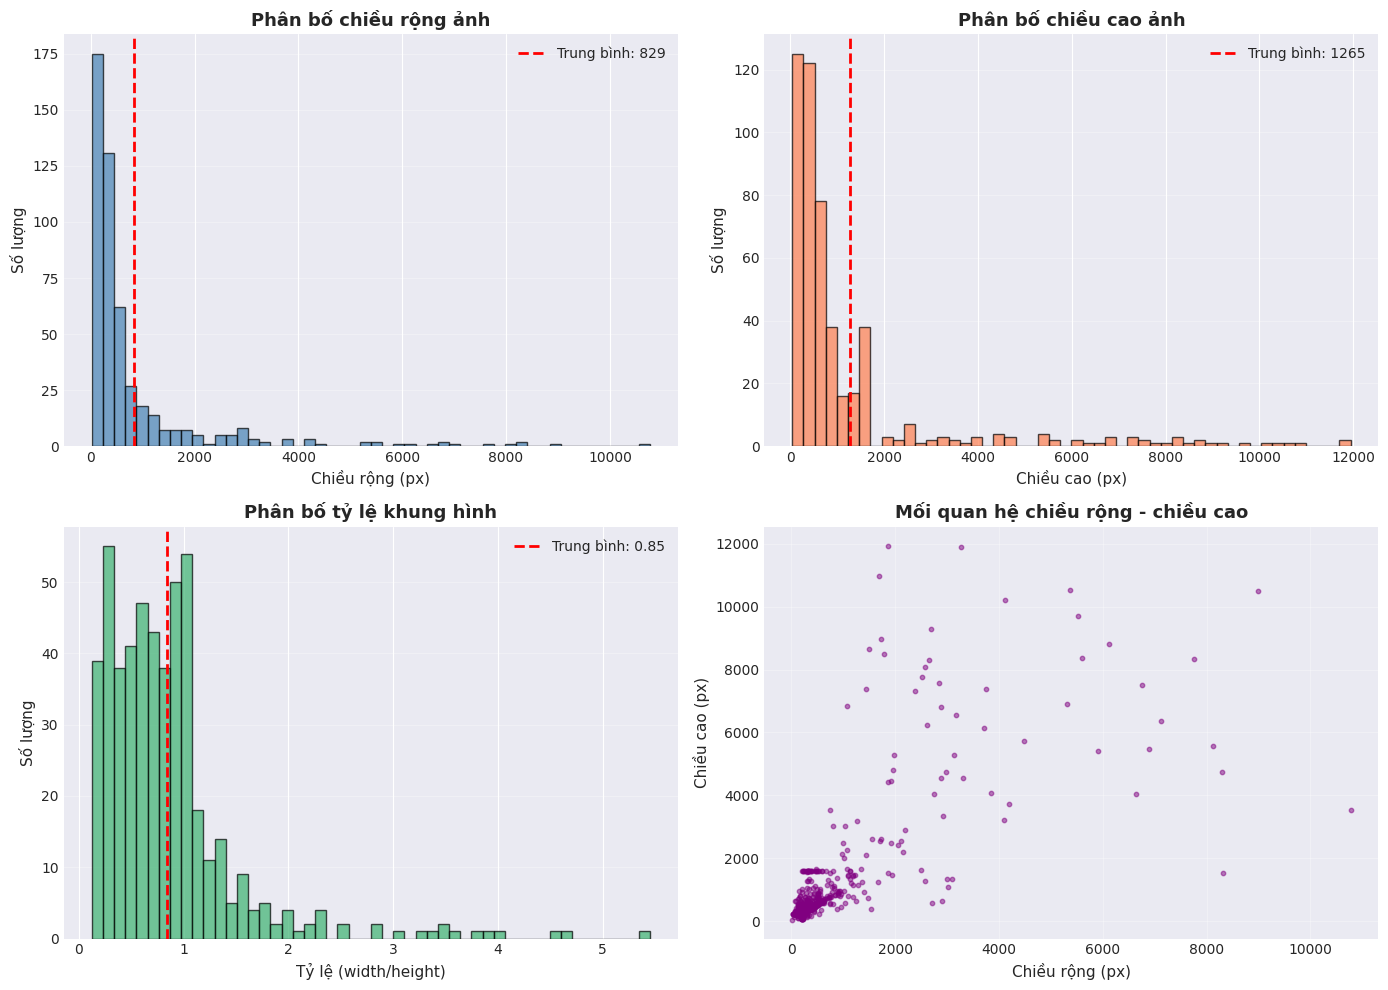

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram chiều rộng
axes[0, 0].hist(chieu_rong, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.mean(chieu_rong), color='red', linestyle='--', linewidth=2, 
                   label=f'Trung bình: {np.mean(chieu_rong):.0f}')
axes[0, 0].set_title('Phân bố chiều rộng ảnh', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Chiều rộng (px)', fontsize=11)
axes[0, 0].set_ylabel('Số lượng', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram chiều cao
axes[0, 1].hist(chieu_cao, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(np.mean(chieu_cao), color='red', linestyle='--', linewidth=2,
                   label=f'Trung bình: {np.mean(chieu_cao):.0f}')
axes[0, 1].set_title('Phân bố chiều cao ảnh', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Chiều cao (px)', fontsize=11)
axes[0, 1].set_ylabel('Số lượng', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Histogram tỷ lệ khung hình
axes[1, 0].hist(ty_le, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(np.mean(ty_le), color='red', linestyle='--', linewidth=2,
                   label=f'Trung bình: {np.mean(ty_le):.2f}')
axes[1, 0].set_title('Phân bố tỷ lệ khung hình', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Tỷ lệ (width/height)', fontsize=11)
axes[1, 0].set_ylabel('Số lượng', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Scatter plot mối quan hệ width-height
axes[1, 1].scatter(chieu_rong, chieu_cao, alpha=0.5, s=10, c='purple')
axes[1, 1].set_title('Mối quan hệ chiều rộng - chiều cao', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Chiều rộng (px)', fontsize=11)
axes[1, 1].set_ylabel('Chiều cao (px)', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Phân tích chi tiết từng lớp trong tập train

In [14]:
# Phân tích chi tiết từng lớp trong tập Train
print("\nThống kê chi tiết theo từng lớp:")

for ten_lop in train_counts.keys():
    thu_muc_lop = TRAIN_DIR / ten_lop
    danh_sach_anh = list(thu_muc_lop.glob("*.jpg")) + list(thu_muc_lop.glob("*.png"))
    
    # Lấy mẫu để phân tích
    mau_phan_tich = min(100, len(danh_sach_anh))
    anh_mau = np.random.choice(danh_sach_anh, mau_phan_tich, replace=False)
    
    chieu_rong_lop = []
    chieu_cao_lop = []
    
    for duong_dan_anh in anh_mau:
        try:
            anh = Image.open(duong_dan_anh)
            w, h = anh.size
            chieu_rong_lop.append(w)
            chieu_cao_lop.append(h)
        except:
            continue
    
    print(f"\nLớp '{ten_lop}':")
    print(f"  Tổng số ảnh: {len(danh_sach_anh)}")
    print(f"  Kích thước trung bình: {np.mean(chieu_rong_lop):.0f} x {np.mean(chieu_cao_lop):.0f} px")
    print(f"  Kích thước min: {np.min(chieu_rong_lop)} x {np.min(chieu_cao_lop)} px")
    print(f"  Kích thước max: {np.max(chieu_rong_lop)} x {np.max(chieu_cao_lop)} px")


Thống kê chi tiết theo từng lớp:

Lớp 'bacterial_leaf_blight':
  Tổng số ảnh: 781
  Kích thước trung bình: 2339 x 3654 px
  Kích thước min: 32 x 55 px
  Kích thước max: 7610 x 12000 px

Lớp 'brown_spot':
  Tổng số ảnh: 795
  Kích thước trung bình: 288 x 429 px
  Kích thước min: 46 x 58 px
  Kích thước max: 1200 x 1598 px

Lớp 'healthy':
  Tổng số ảnh: 794
  Kích thước trung bình: 315 x 568 px
  Kích thước min: 45 x 103 px
  Kích thước max: 1267 x 1878 px

Lớp 'leaf_blast':
  Tổng số ảnh: 774
  Kích thước trung bình: 620 x 722 px
  Kích thước min: 36 x 110 px
  Kích thước max: 2885 x 2478 px


### AUG thực hiện trong script train model !